##### Intro to Quantum Programming - Spring 2025
## Homework 4: Due 04/04/25

For each exercise below, add as many cells as you want. To evaluate your submission, I will do **Restart and Run All**. . For help with Markdown, see [this link](https://www.markdownguide.org/).

In [2]:
# Here's a cell for import statements... add more if necessary (or just import below as needed)
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit.library import *
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

import numpy as np

## Import sv_disc [Python File to Display Quibit States in Disc format]
import sys
# Add the directory where sv_disc.py is located
sys.path.append('/home/connor/QuantumComputing/Qiskit')
from sv_disc import *



For some of the exercises below, you may use high-level circuit from [`qiskit.circuit.library`](https://docs.quantum.ibm.com/api/qiskit/circuit_library). Refer to each problem see what you are and are not allowed to use.

----
#### Exercise 4.1 (40%): QFT Adder

The QFT circuit can be used as a building block for basic arithmetic, as discussed in [this blog](https://pennylane.ai/qml/demos/tutorial_qft_arithmetics) by Pennylane. The QFT allows us to add two quantum registers without using ancilla qubits. The idea is to use QFT to convert into the "frequency" domain. Then use use the other circuit to add phase shifts, which changes the frequency of the signal, and then use inverse-QFT to revert back to a number.

The Pennylane tutorial shows an out-of-band adder: $$|0\rangle|b\rangle|a\rangle \mapsto |a+b\rangle|b\rangle|a\rangle,$$ while Qiskit's `DraperQFTAdder` does an in-place adder: $$|b\rangle|a\rangle \mapsto |a+b\rangle|a\rangle.$$

In the cells below, implement an *in-place* QFT adder for two 4-qubit numbers without using the `DraperQFTAdder` circuit.  In other words, use `QFT` and controlled-`RZ` gates to implement the adder.  To get full points, draw the circuit and demonstrate that it works for multiple choices of $a$ and $b$.

## **Additional Markdown Cell**
##### **Added By Connor**
### Why Does QFT-Based Addition Work?

The in-place QFT adder uses the properties of the **Quantum Fourier Transform (QFT)** to perform addition by modifying the phase of a quantum register.

Instead of simulating classical carry logic, this method performs the addition by encoding numbers in **quantum phases**, adjusting those phases, and then decoding the result back to the computational basis.

---

#### Step-by-Step Explanation

##### 1. What Are Basis States and Superpositions?

In quantum computing, an **n-qubit register** exists in a space spanned by the **computational basis states**:

$$
|0\rangle, |1\rangle, |2\rangle, \dots, |2^n - 1\rangle
$$

These represent binary values from 0 to $2^n - 1$, encoded in qubits. For example, for 3 qubits, the basis states include $|000\rangle, |001\rangle, \dots, |111\rangle$.

A **superposition** is a linear combination of these basis states:

$$
|\psi\rangle = \sum_{k=0}^{2^n - 1} \alpha_k |k\rangle
$$

Here, each $\alpha_k$ is a **complex amplitude**. The square magnitude $|\alpha_k|^2$ is the probability of measuring the state $|k\rangle$.

---

##### 2. What Is a "Superposition of Phases"?

When we say the QFT transforms a state into a "superposition of phases," we mean it converts a basis state like $|b\rangle$ into a quantum state where all basis states $|k\rangle$ are present, but each with a **complex phase factor** based on $b$:

$$
\text{QFT}|b\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i b k / 2^n} |k\rangle
$$

Each amplitude now includes a phase: $e^{2\pi i b k / 2^n}$. This is the key to how QFT encodes numerical values in the **frequency domain**.

---

##### 3. How Does QFT Addition Work?

To add two quantum numbers $a$ and $b$ without using ancilla qubits:

- Prepare a quantum state $|b\rangle|a\rangle$
- Apply the **QFT** to $|b\rangle$, converting it to the phase-encoded state above
- Use **controlled phase rotations** from the $|a\rangle$ qubits to modify the phase of each component in $|b\rangle$
  - This introduces an extra phase factor $e^{2\pi i a k / 2^n}$
  - The combined phase becomes $e^{2\pi i (a + b) k / 2^n}$
- Apply the **inverse QFT** to $|b\rangle$, converting it back into the computational basis

Mathematically:

$$
\frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i (a + b) k / 2^n} |k\rangle \xrightarrow{\text{QFT}^{-1}} |a + b\rangle
$$

Now the $|b\rangle$ register holds $a + b$, while $|a\rangle$ is unchanged.

---

#### 4. What Does the QFT Actually Do?

The **Quantum Fourier Transform** is a unitary operation (reversible) that maps a basis state $|x\rangle$ into a superposition over $|k\rangle$, where each term has a different phase:

$$
\text{QFT}|x\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i x k / 2^n} |k\rangle
$$

This phase encoding is analogous to a classical Discrete Fourier Transform (DFT). It does not destroy information — instead, it redistributes it across phases.

Since the QFT is **unitary**, applying its inverse $\text{QFT}^{-1}$ perfectly reconstructs the original input state.

---

#### 5. Why Is No Information Lost?

Even though phase encoding may seem abstract, **no information is discarded** because:

- The QFT preserves all input data in phase form
- The inverse QFT restores that data
- All operations (QFT, controlled phase gates, and inverse QFT) are **reversible**

In this adder circuit:
- You never measure until the end
- You don’t collapse the wavefunction prematurely
- You only modify phases, which is safe until final measurement

This means your result is **exact**, and you still get a valid, deterministic output: $|a + b\rangle|a\rangle$

---

#### Summary

- The QFT encodes numbers as phase angles in a uniform superposition
- Controlled phase rotations shift those angles based on the second number
- The inverse QFT decodes the result back into the standard basis
- The final state is $|a + b\rangle|a\rangle$, with no ancilla qubits or classical carry logic required



Test: a = 3, b = 5
Expected output (|a + b⟩|a⟩): |10000011>

Initial Bloch vectors for all qubits:


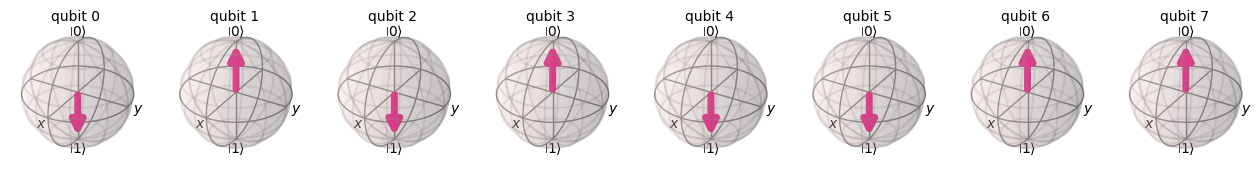


Final Bloch vectors after QFT addition:


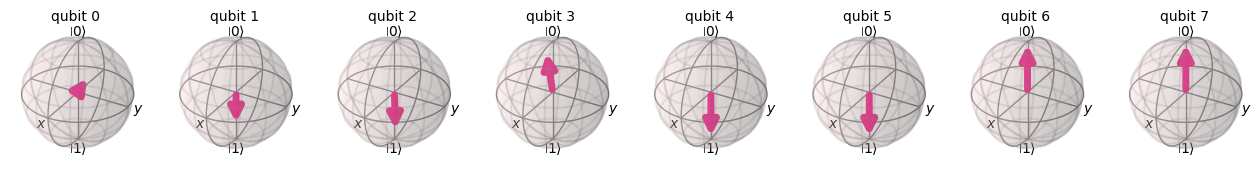


Test: a = 3, b = 5
Expected output (|a + b⟩|a⟩): |10000011>

Non-zero basis state probabilities:
|00110000⟩ -> 0.0043
|00110001⟩ -> 0.0050
|00110010⟩ -> 0.0065
|00110011⟩ -> 0.0097
|00110100⟩ -> 0.0176
|00110101⟩ -> 0.0464
|00110110⟩ -> 0.4066
|00110111⟩ -> 0.4066
|00111000⟩ -> 0.0464
|00111001⟩ -> 0.0176
|00111010⟩ -> 0.0097
|00111011⟩ -> 0.0065
|00111100⟩ -> 0.0050
|00111101⟩ -> 0.0043
|00111110⟩ -> 0.0039
|00111111⟩ -> 0.0039


In [3]:

def qft_adder(a_val, b_val, a_bits=4, b_bits=4):
    qreg_b = QuantumRegister(b_bits, name="b")
    qreg_a = QuantumRegister(a_bits, name="a")
    creg = ClassicalRegister(a_bits + b_bits)
    qc = QuantumCircuit(qreg_b, qreg_a, creg)

    # Step 0: Initialize a and b
    for i in range(a_bits):
        if (a_val >> i) & 1:
            qc.x(qreg_a[i])
    for i in range(b_bits):
        if (b_val >> i) & 1:
            qc.x(qreg_b[i])

    # Step 1: Apply QFT to b register
    qc.append(QFT(b_bits, do_swaps=False).to_gate(), qreg_b[:])

    # Step 2: Add phase shifts to b based on a (simulate addition)
    for i in range(a_bits):
        weight = 2 ** (a_bits - i - 1)
        for j in range(b_bits):
            angle = 2 * np.pi * weight / (2 ** (j + 1))
            qc.cp(angle, qreg_a[i], qreg_b[j])


    # Step 3: Uncompute the phase shift controls (none needed with in-place addition)
    # Note: Because no ancillas or additional entanglement is introduced, nothing to uncompute explicitly

    # Step 4: Apply inverse QFT to b register
    qc.append(QFT(b_bits, do_swaps=False).inverse().to_gate(), qreg_b[:])

    # Step 5: Measure all qubits
    for i in range(b_bits):
        qc.measure(qreg_b[i], creg[i])
    for i in range(a_bits):
        qc.measure(qreg_a[i], creg[b_bits + i])

    return qc

def run_test(a_val, b_val, a_bits=4, b_bits=4, display_mode="bloch"):
    qreg_b = QuantumRegister(b_bits, name="b")
    qreg_a = QuantumRegister(a_bits, name="a")
    qc = QuantumCircuit(qreg_b, qreg_a)

    for i in range(a_bits):
        if (a_val >> i) & 1:
            qc.x(qreg_a[i])
    for i in range(b_bits):
        if (b_val >> i) & 1:
            qc.x(qreg_b[i])

    total_bits = a_bits + b_bits

    # Save initial statevector
    sv = Statevector.from_instruction(qc)

    # QFT Adder logic
    qc.append(QFT(b_bits, do_swaps=False).to_gate(), qreg_b[:])
    for i in range(a_bits):
        for j in range(b_bits):
            angle = 2 * np.pi / (2 ** (i + j + 1))
            qc.cp(angle, qreg_a[i], qreg_b[j])
    qc.append(QFT(b_bits, do_swaps=False).inverse().to_gate(), qreg_b[:])

    # Final statevector
    final_sv = Statevector.from_instruction(qc)

    expected = (a_val + b_val) % (2 ** b_bits)
    expected_bin = f"|{expected:0{b_bits}b}{a_val:0{a_bits}b}>"
    print(f"\nTest: a = {a_val}, b = {b_val}")
    print(f"Expected output (|a + b⟩|a⟩): {expected_bin}")

    if display_mode == "bloch":
        print("\nInitial Bloch vectors for all qubits:")
        display(plot_bloch_multivector(sv))

        print("\nFinal Bloch vectors after QFT addition:")
        display(plot_bloch_multivector(final_sv))

    elif display_mode == "text":
        print("\nNon-zero basis state probabilities:")
        for i, amp in enumerate(final_sv.data):
            prob = abs(amp) ** 2
            if prob > 1e-6:
                label = format(i, f'0{total_bits}b')
                print(f"|{label}⟩ -> {prob:.4f}")

    else:
        print(f"\nUnknown display mode: '{display_mode}'")

# --- Example test cases ---
run_test(a_val=3, b_val=5, display_mode="bloch")    # Expect 3 + 5 = 8 → |10000011⟩
run_test(a_val=3, b_val=5, display_mode="text")     # Expect 3 + 5 = 8 → |10000011⟩




# from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.circuit.library import QFT
# import numpy as np

# def add_k_fourier(k, qreg_target, qc):
#     """Apply QFT-based phase rotations to add classical value k."""
#     for j, qubit in enumerate(qreg_target):
#         angle = 2 * np.pi * k / (2 ** (j + 1))
#         qc.rz(angle, qubit)

# def controlled_add_register(qc, qreg_control, qreg_target):
#     n = len(qreg_control)
#     for i in range(n):
#         ctrl_val = 2 ** i  # NOT 2**(n - i - 1)
#         for j, qubit in enumerate(qreg_target):
#             angle = 2 * np.pi * ctrl_val / (2 ** (j + 1))
#             qc.cp(angle, qreg_control[i], qubit)


# def sum2_qiskit(m_val, k_val, m_bits=3, k_bits=3, sol_bits=4):
#     qreg_m = QuantumRegister(m_bits, name='m')
#     qreg_k = QuantumRegister(k_bits, name='k')
#     qreg_sol = QuantumRegister(sol_bits, name='sol')
#     qc = QuantumCircuit(qreg_m, qreg_k, qreg_sol)

#     # Step 0: Initialize m and k
#     for i in range(m_bits):
#         if (m_val >> i) & 1:
#             qc.x(qreg_m[i])
#     for i in range(k_bits):
#         if (k_val >> i) & 1:
#             qc.x(qreg_k[i])

#     sol_reversed = list(reversed(qreg_sol))

#     # Step 1: QFT on solution register
#     qc.append(QFT(sol_bits, do_swaps=False).to_gate(), sol_reversed)

#     # Step 2: Controlled addition of m and k to solution
#     controlled_add_register(qc, qreg_m, sol_reversed)
#     controlled_add_register(qc, qreg_k, sol_reversed)

#     # Step 3: Inverse QFT
#     qc.append(QFT(sol_bits, do_swaps=False).inverse().to_gate(), sol_reversed)

#     return qc

# from qiskit.quantum_info import Statevector

# def run_test(m_val, k_val, expected_sum, bits=4):
#     m_bits = k_bits = sol_bits = bits
#     qc = sum2_qiskit(m_val, k_val, m_bits, k_bits, sol_bits)
#     total_qubits = m_bits + k_bits + sol_bits

#     # Simulate statevector
#     sv = Statevector.from_instruction(qc)
#     index = np.argmax(np.abs(sv.data) ** 2)

#     # Get bitstring in little endian (Qiskit's convention)
#     bitstring = format(index, f'0{total_qubits}b')[::-1]

#     # Extract registers: solution (0:4), k (4:8), m (8:12), then reverse each to big endian
#     sol_bin = bitstring[0:sol_bits][::-1]
#     k_bin   = bitstring[sol_bits:sol_bits + k_bits][::-1]
#     m_bin   = bitstring[sol_bits + k_bits:][::-1]

#     print(f"\nTest: {m_val} + {k_val} = {expected_sum}")
#     print(f"Raw bitstring (little endian): {bitstring[::-1]}")
#     print(f"         m bits: {m_bin}")
#     print(f"         k bits: {k_bin}")
#     print(f"     solution ⟩: {sol_bin}")
#     print(f"Expected ⟩:      {format(expected_sum, f'0{sol_bits}b')}")





# # # --- Run Example Tests ---
# run_test(m_val=1, k_val=2, expected_sum=3)
# run_test(m_val=3, k_val=5, expected_sum=8)
# run_test(m_val=7, k_val=3, expected_sum=10)
# run_test(m_val=5, k_val=0, expected_sum=5)
# run_test(m_val=15, k_val=1, expected_sum=16 % 16)  # optional overflow test


----
#### Exercise 4.2 (30%): Solving an equation with Grover's Algorithm

Use Grover's algorithm to find a solution to the following equation:$$a + b = 17.$$ In other words, find values $a$ and $b$ such that they add up to 17.  (Hint: Create an oracle that determines whether $a+b = 17$ is true.)

How many iterations of Grover do you think is needed to maximimize the probability of finding a solution?  In your code below, show the success rate of executing the circuit 100 times for Grover iterations ranging from 2 to 5. A *success* is finding any correct solution.

For this exercise, you can use any of the circuits from the library, including adders, boolean logic, etc.  You don't need to draw the cirt

----
#### Exercise 4.3 (30%): Factoring with Grover's Algorithm

You can also do factoring with Grover. It doesn't give an exponential speedup, however. Use the equation-solving approach from above to find a solution to find the factors of 35: $ab = 35$. Note: restrict the number of bits used for the factors to avoid find a solution of $a = 1, b = 35$.

For this exercise, you can use any of the circuits from the library. Use an appropriate number of Grover iterations to find a solution with high probability.